In [5]:
import gurobi_logtools as glt
import pandas as pd
import plotly.express as px
import plotly.subplots as sp
import plotly.graph_objects as go

In [65]:
config = "SPComp"
F = ["NU", "SU", "RU", "HU", "NUspb", "SUspb", "RUspb", "HUspb"]
N = ["10", "15", "20", "25", "35", "50"]
I = ["0"]
P = ["010", "111"]
O = ["StripPacking"]

Params = [(f,p,o,n,i)  for f in F  for p in P  for o in O  for n in N  for i in I]
Files = [f"{o}-{config}/{f}-{p}-{o}-{n}-{i}.log"  for (f,p,o,n,i) in Params]
Results = glt.parse(Files)
Info = pd.DataFrame({'Formulation': [f    for (f,p,o,n,i) in Params], 'N': [n   for (f,p,o,n,i) in Params]})
Summary = Results.summary().join(Info)
Progress = Results.progress("nodelog")
fs = []
ns = []
ps = []
hs = []
vs = []
os = []

for index, row in Progress.iterrows():
    file = row['LogFilePath']
    name = file.split('/')[1]
    dash = name.index('-')
    fs.append(name[0:dash])
    os.append(file[0:dash])
    if (name[dash+1],name[dash+3]) == ('0','0'):
        ps.append('off')
    else:
        ps.append('on')
    
    ns.append(name[-8:-6])
    if 'spb' in name:
        vs.append('Seq & Br')
    elif 'sp' in name:
        vs.append('Sequence')
    elif 'b' in name:
        vs.append('Branch')
    else:
        vs.append('Standard')

Progress['Formulation'] = fs
Progress['N'] = ns
Progress['C & H'] = ps
Progress['Variant'] = vs

In [107]:
Filter = Progress[Progress['LogFilePath'].str.contains('SU') & Progress['LogFilePath'].str.contains('-25')]
glt.plot(Filter, type='line', color='C & H', y='Gap')

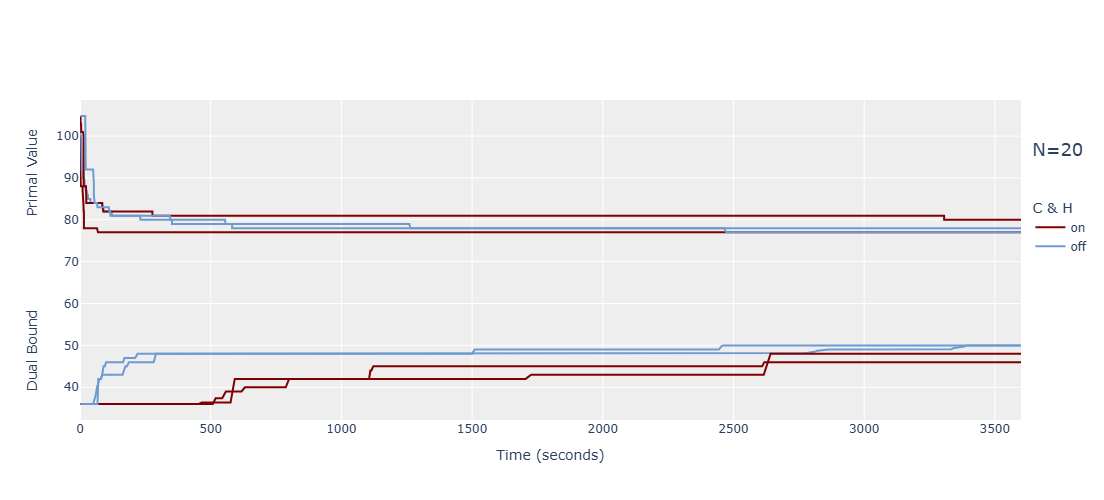

In [63]:
Forms=F #["NU", "SU", "RU", "HU", "SBL", "SBM"]
N=['20']

Filter = Progress[Progress['Formulation'].isin(Forms) 
                & Progress['N'].isin(N) 
                ]

fig = go.Figure()

for f in Forms:
    Filter2 = Filter[Filter['Formulation'].isin([f])
                    & Filter['C & H'].isin(['on'])
                    ]
    fig.add_trace(go.Scatter(x=Filter2['Time'], y=Filter2['Incumbent'], mode='lines', name='on', line=dict(color='#800000'), showlegend=False))
    fig.add_trace(go.Scatter(x=Filter2['Time'], y=Filter2['BestBd'], mode='lines', name='on', line=dict(color='#800000'), showlegend=False))
    
    Filter3 = Filter[Filter['Formulation'].isin([f])
                    & Filter['C & H'].isin(['off'])
                    ]
    fig.add_trace(go.Scatter(x=Filter3['Time'], y=Filter3['Incumbent'], mode='lines',name='off', line=dict(color='#6D9BD1'), showlegend=False))
    fig.add_trace(go.Scatter(x=Filter3['Time'], y=Filter3['BestBd'], mode='lines',name='off', line=dict(color='#6D9BD1'), showlegend=False))

fig.add_trace(go.Scatter(
    x=[None],
    y=[None],
    mode='lines',
    name='on',
    line=dict(color='#800000')
))
fig.add_trace(go.Scatter(
    x=[None],
    y=[None],
    mode='lines',
    name='off',
    line=dict(color='#6D9BD1')
))

fig.update_layout(
    xaxis_title='Time (seconds)',
    yaxis_title='Dual Bound                   Primal Value',
    height=500,
    plot_bgcolor='rgba(200, 200, 200, 0.3)',
    legend_title_text='C & H',
    title=dict(
        text=f"N={N[0]}",  # your title
        x=0.935,                         
        y=0.7,                       
        xanchor='left',
        yanchor='middle',
        font=dict(size=18)
    ),
    legend=dict(
        title_text='C & H',
        x=1.01,   
        y=0.6,
        yanchor='middle',
        traceorder='normal'
    )
)

fig


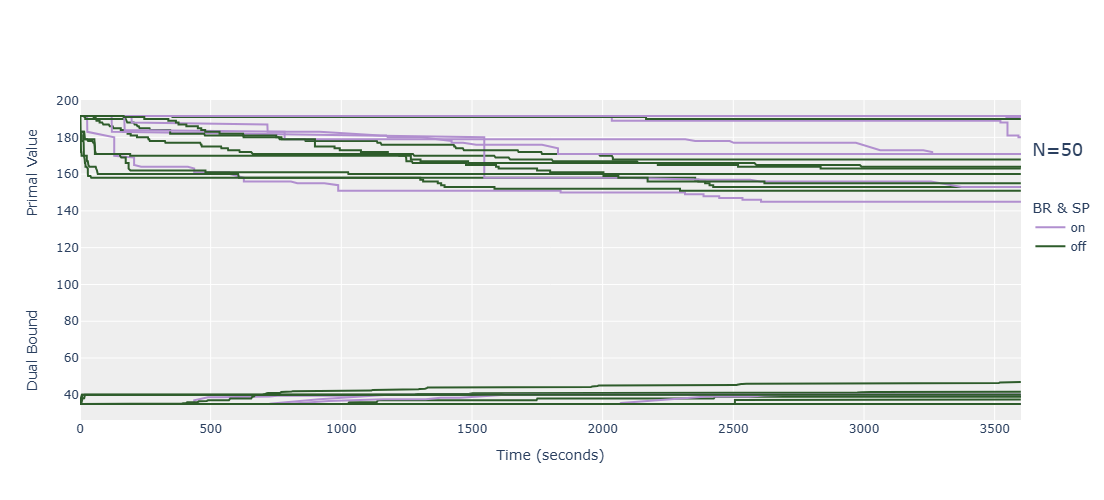

In [67]:
Forms=F #["NU", "SU", "RU", "HU", "SBL", "SBM"]
N=['50']

Filter = Progress[Progress['Formulation'].isin(Forms) 
                & Progress['N'].isin(N) 
                ]

fig = go.Figure()

for f in ['NU', 'SU', 'RU', 'HU']:
    for ch in ['on','off']:
        Filter2 = Filter[Filter['Formulation'].isin([f+"spb"])
                            & Filter['C & H'].isin([ch])
                        ]
        fig.add_trace(go.Scatter(x=Filter2['Time'], y=Filter2['Incumbent'], mode='lines', name='on', line=dict(color='#B18FCF'), showlegend=False))
        fig.add_trace(go.Scatter(x=Filter2['Time'], y=Filter2['BestBd'], mode='lines', name='on', line=dict(color='#B18FCF'), showlegend=False))
        
        Filter3 = Filter[Filter['Formulation'].isin([f])
                            & Filter['C & H'].isin([ch])
                        ]
        fig.add_trace(go.Scatter(x=Filter3['Time'], y=Filter3['Incumbent'], mode='lines',name='off', line=dict(color='#2E5C2B'), showlegend=False))
        fig.add_trace(go.Scatter(x=Filter3['Time'], y=Filter3['BestBd'], mode='lines',name='off', line=dict(color='#2E5C2B'), showlegend=False))
        
fig.add_trace(go.Scatter(
    x=[None],
    y=[None],
    mode='lines',
    name='on',
    line=dict(color='#B18FCF')
))
fig.add_trace(go.Scatter(
    x=[None],
    y=[None],
    mode='lines',
    name='off',
    line=dict(color='#2E5C2B')
))

fig.update_layout(
    xaxis_title='Time (seconds)',
    yaxis_title='Dual Bound                   Primal Value',
    height=500,
    plot_bgcolor='rgba(200, 200, 200, 0.3)',
    legend_title_text='BR & SP',
    title=dict(
        text=f"N={N[0]}",  # your title
        x=0.935,                         
        y=0.7,                       
        xanchor='left',
        yanchor='middle',
        font=dict(size=18)
    ),
    legend=dict(
        title_text='BR & SP',
        x=1.01,   
        y=0.6,
        yanchor='middle',
        traceorder='normal'
    )
)

fig